In [42]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

In [73]:
file_input = "dati2.csv"
esponenziale = False

In [74]:
if file_input == "dati1.csv":
    titolo = "RC in dominio tempo Gruppo 11"
if file_input == "dati2.csv":
    titolo = "RC in dominio tempo Gruppo 15"

xlabel = "$t (\mu s)$"
ylabel = "$V (mV)$"

file_output1 = "residui.txt"
file_output2 = "chi.txt"
grafico_output1 = "grafico.pdf"
grafico_output2 = "residui.pdf"
grafico_output3 = "chi.pdf"

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3232/3362035630.py:6: SyntaxWarning: invalid escape sequence '\m'
  xlabel = "$t (\mu s)$"


### 1. Lettura

In [75]:
data = f.csv_to_dict(file_input)

In [76]:
gf.display_dizionario(data)

tempo,[ 3.2 5. 6.8 8.8 10.8 13.2 15.4 18.2 20.8 24.2]
voltaggio,[892. 844. 796. 744. 696. 644. 600. 552. 504. 456.]


### 2. Analisi

Regressione

In [77]:
# Fit Esponenziale
if esponenziale:
    xdata = np.array([data["tempo"],np.full_like(data["tempo"], 0.5)])
    ydata = np.array([data["voltaggio"],
                      np.sqrt(np.full_like(data["voltaggio"], 20)**2
                              + (1/np.sqrt(3) * (3/100) * data["voltaggio"])**2)])

    def modello(par, x):
        return par[0] + par[1]*np.exp(-x/par[2])

    param_labels = ['offset','V0','tau'] # Verranno visualizzati poi nel grafico

    anal = f.fit(xdata,ydata,modello,[0.1,992,29]) # Parametri iniziali

# Fit Lineare
else:
    xdata = np.array([data["tempo"],np.full_like(data["tempo"], 0.5)])
    ydata = np.array([np.log(data["voltaggio"]), (np.sqrt(np.full_like(data["voltaggio"], 20)**2 + (1/np.sqrt(3) * (3/100) * data["voltaggio"])**2) ) /  data["voltaggio"]])

    def modello(par, x):
        return par[0] + par[1]*x

    param_labels = ['intercetta', 'pendenza'] # Verranno visualizzati poi nel grafico

    anal = f.fit(xdata,ydata,modello,[1,-1]) # Parametri iniziali

f.inizializza_output("regressione.txt")
gf.salva_analisi(anal, param_labels, "regressione.txt")

Residui

In [78]:
f.inizializza_output(file_output1)
res = f.residui(xdata,ydata,anal[:,0],modello,file_output1,titolo)

Chi Quadro

In [79]:
f.inizializza_output(file_output2)
chi = f.chi_quadro(xdata,ydata,anal[:,0],modello,file_output2,titolo)

### 3. Grafici

Regressione

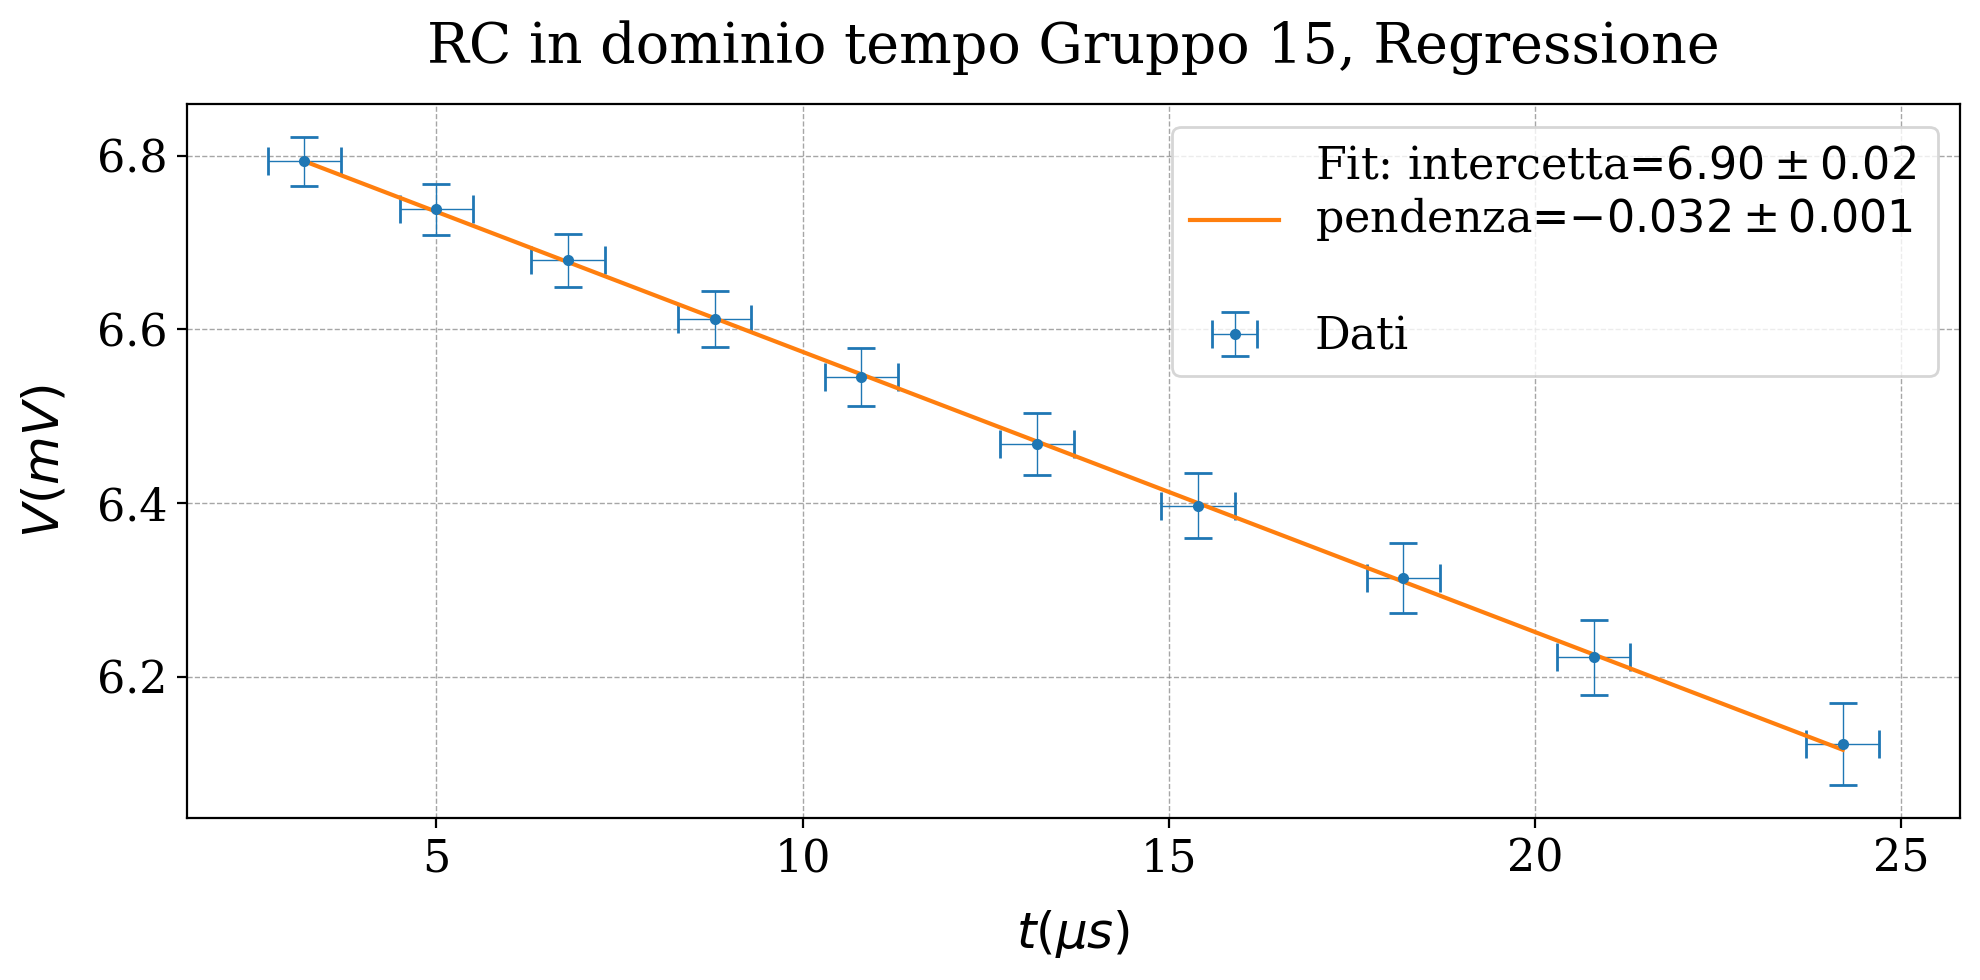

In [80]:
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + ", Regressione",xlabel=xlabel,ylabel=ylabel)
# Grafico dei dati con errori
ax.errorbar(xdata[0],ydata[0],xerr=xdata[1],yerr=ydata[1],
            label="Dati", **gf.errorbar_params, color = gf.colori[0])
# Grafico del fit
fit_label = "Fit: " + "".join(
    f"{param_labels[i]}={gf.formatta_errore(anal[i,0],anal[i,1])}\n" for i in range(len(param_labels))
)
x_fit = np.linspace(min(xdata[0]), max(xdata[0]), 500)
ax.plot(x_fit,modello(anal[:,0],x_fit),
        label=fit_label, **gf.plot_params, color = gf.colori[1])

ax.legend()

gf.salva_grafico(fig,grafico_output1)

Residui

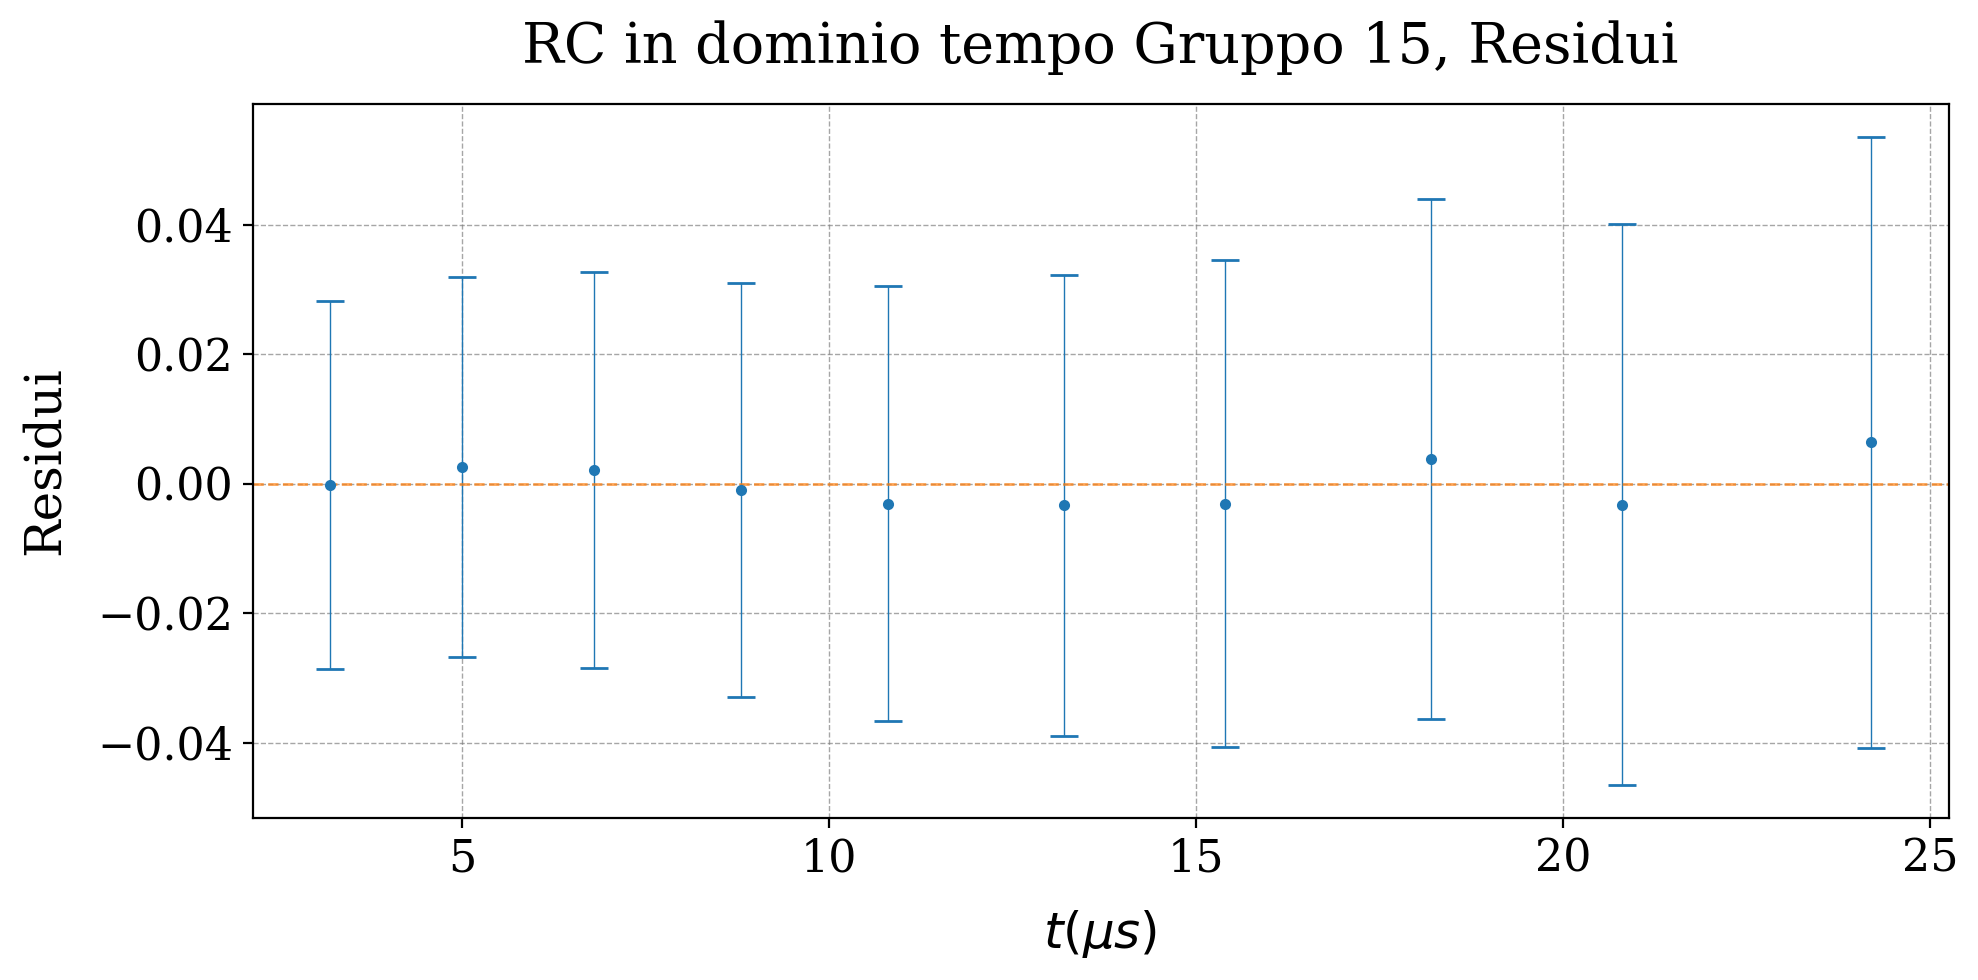

In [81]:
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + ", Residui",xlabel=xlabel,ylabel="Residui")

ax.errorbar(res[0],res[1],yerr=res[2],
            **gf.errorbar_params, color=gf.colori[0])
ax.axhline(0,
           **gf.line_params, color=gf.colori[1])

gf.salva_grafico(fig,grafico_output2)

Chi Quadro

<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3232/1845354324.py:2: SyntaxWarning: invalid escape sequence '\c'
  gf.parametri_grafico(ax,titolo + r", $\chi^2$",xlabel=xlabel,ylabel="$\chi^2$")


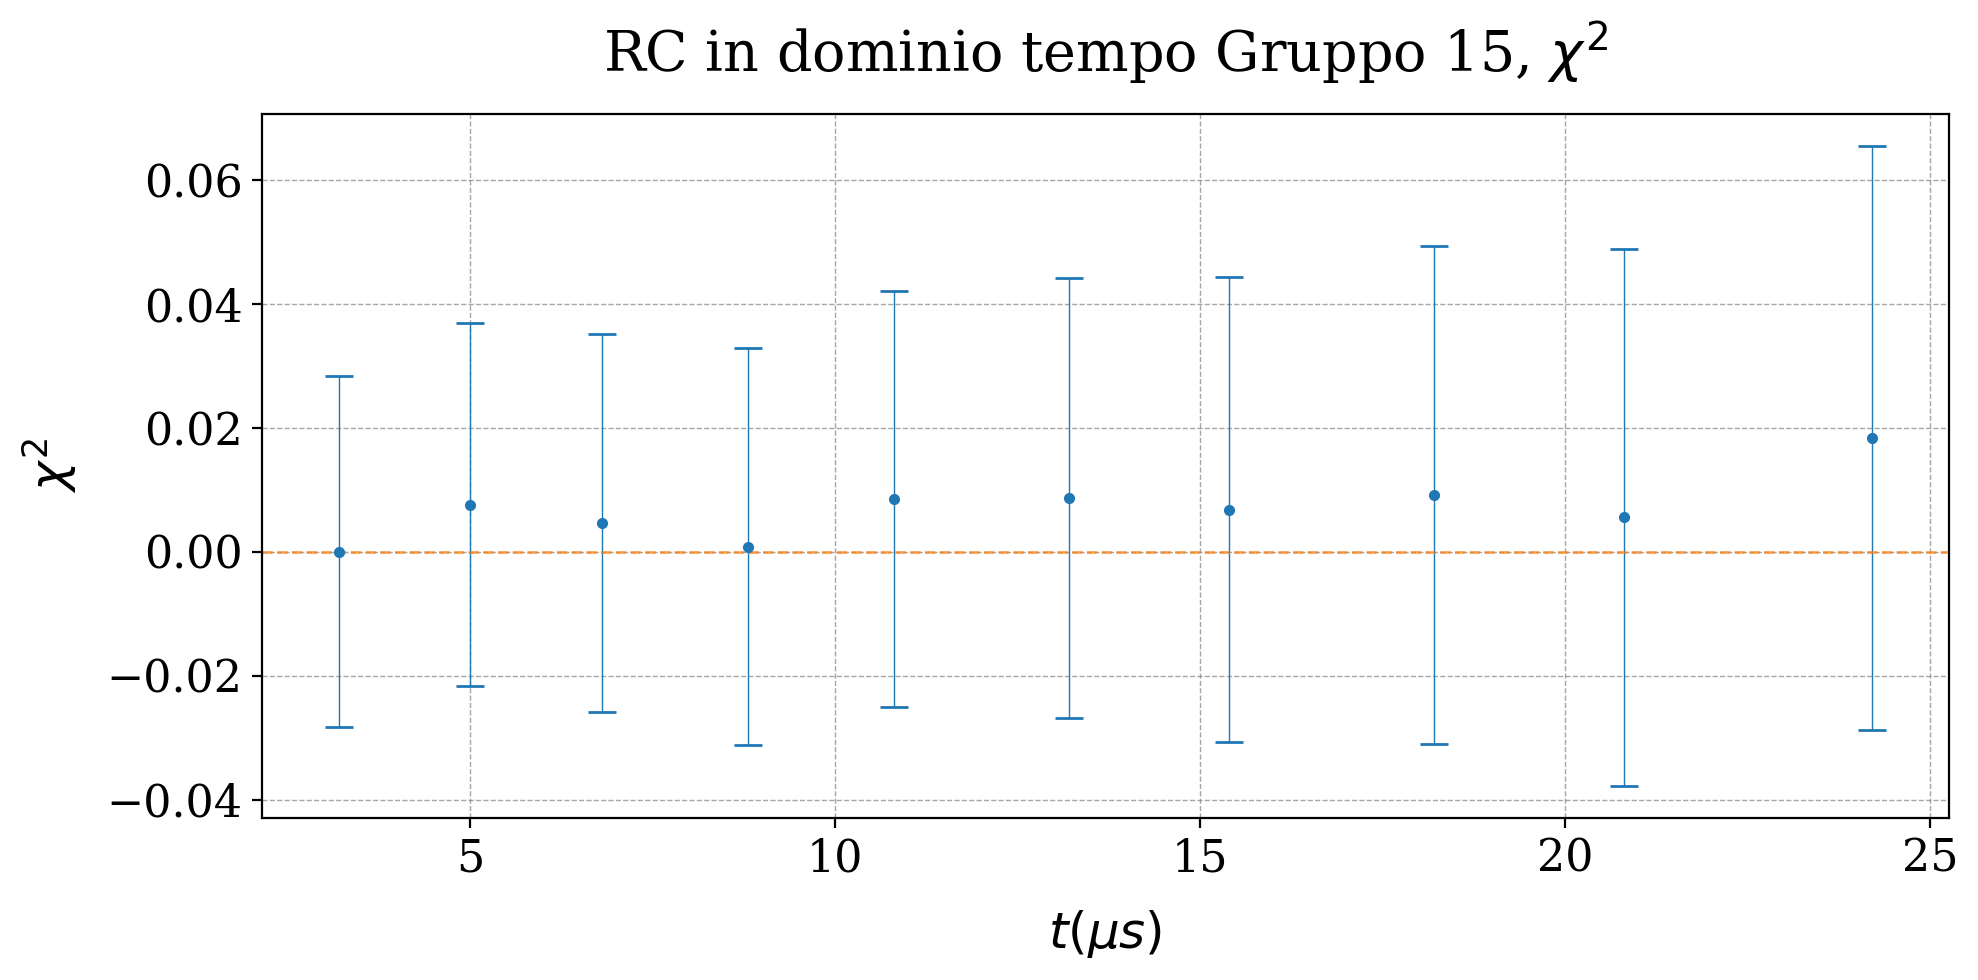

In [82]:
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + r", $\chi^2$",xlabel=xlabel,ylabel="$\chi^2$")

ax.errorbar(chi[0],chi[1],yerr=chi[2],
            **gf.errorbar_params, color=gf.colori[0])
ax.axhline(0,
           **gf.line_params, color=gf.colori[1])

gf.salva_grafico(fig,grafico_output3)